# Questão 4

Análise e remoção de ruído do sinal em `../data/leleccum.mat`, comparando
uma estratégia por wavelets (`db4`) com uma estratégia por limiarização na DFT.


In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import pywt
from scipy.io import loadmat, wavfile
from scipy.linalg import hadamard
from scipy import signal

plt.style.use('seaborn-v0_8-whitegrid')

CWD = Path.cwd().resolve()
if (CWD / 'pratica_5' / 'Aula_Prática_5.pdf').exists():
    REPO_ROOT = CWD
    PRACTICE_DIR = CWD / 'pratica_5'
elif (CWD / 'Aula_Prática_5.pdf').exists():
    PRACTICE_DIR = CWD
    REPO_ROOT = CWD.parent
else:
    PRACTICE_DIR = CWD
    REPO_ROOT = CWD.parent

DATA_DIR = REPO_ROOT / 'data'

def display_rows(rows, float_digits=6):
    if not rows:
        print('Sem dados para exibir.')
        return

    headers = list(rows[0].keys())
    formatted_rows = []
    for row in rows:
        formatted = []
        for header in headers:
            value = row[header]
            if isinstance(value, float):
                formatted.append(f'{value:.{float_digits}f}')
            else:
                formatted.append(str(value))
        formatted_rows.append(formatted)

    widths = []
    for idx, header in enumerate(headers):
        content_width = max(len(row[idx]) for row in formatted_rows)
        widths.append(max(len(header), content_width))

    header_line = ' | '.join(header.ljust(widths[idx]) for idx, header in enumerate(headers))
    separator = '-+-'.join('-' * width for width in widths)
    print(header_line)
    print(separator)
    for row in formatted_rows:
        print(' | '.join(value.ljust(widths[idx]) for idx, value in enumerate(row)))


def mse(reference, estimate):
    reference = np.asarray(reference, dtype=np.float64)
    estimate = np.asarray(estimate, dtype=np.float64)
    return float(np.mean((reference - estimate) ** 2))


def plot_spectrum(ax, signal_in, fs, title, xlim=None):
    freqs = np.fft.rfftfreq(len(signal_in), d=1 / fs)
    mag = np.abs(np.fft.rfft(signal_in))
    ax.plot(freqs, mag)
    ax.set_title(title)
    ax.set_xlabel('Frequencia (Hz)')
    ax.set_ylabel('Magnitude')
    if xlim is not None:
        ax.set_xlim(*xlim)
    ax.grid(True, alpha=0.3)


def coeffs_table(wavelet_name):
    w = pywt.Wavelet(wavelet_name)
    return [
        {'Filtro': 'dec_lo', 'Coeficientes': np.array2string(np.array(w.dec_lo), precision=8, separator=', ')},
        {'Filtro': 'dec_hi', 'Coeficientes': np.array2string(np.array(w.dec_hi), precision=8, separator=', ')},
        {'Filtro': 'rec_lo', 'Coeficientes': np.array2string(np.array(w.rec_lo), precision=8, separator=', ')},
        {'Filtro': 'rec_hi', 'Coeficientes': np.array2string(np.array(w.rec_hi), precision=8, separator=', ')},
    ]


def plot_wavelet_decomposition(signal_in, coeffs, title):
    levels = len(coeffs) - 1
    fig, axes = plt.subplots(levels + 2, 1, figsize=(12, 2.3 * (levels + 2)))
    axes[0].plot(signal_in)
    axes[0].set_title(f'{title} - sinal original')
    axes[0].set_xlabel('Amostra normalizada')
    axes[0].set_ylabel('Amplitude')

    axes[1].plot(coeffs[0])
    axes[1].set_title(f'{title} - aproximacao A{levels}')
    axes[1].set_xlabel('Indice do coeficiente')
    axes[1].set_ylabel('Coef.')

    for idx, detail in enumerate(coeffs[1:], start=1):
        level = levels - idx + 1
        axes[idx + 1].plot(detail)
        axes[idx + 1].set_title(f'{title} - detalhe D{level}')
        axes[idx + 1].set_xlabel('Indice do coeficiente')
        axes[idx + 1].set_ylabel('Coef.')

    plt.tight_layout()
    plt.show()


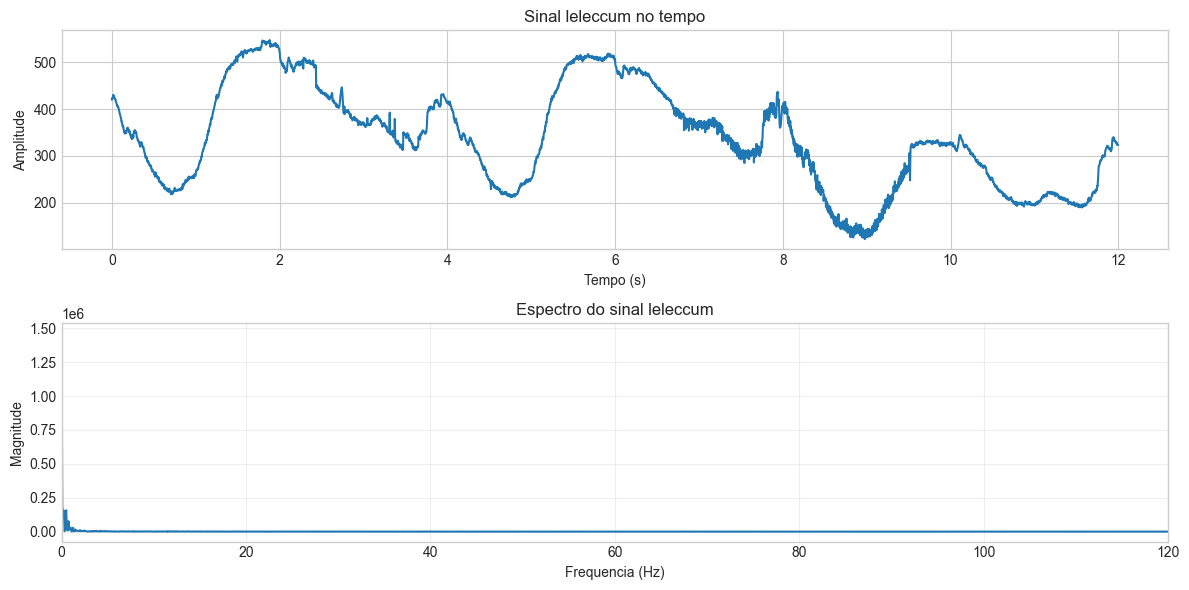

In [2]:
mat = loadmat(DATA_DIR / 'leleccum.mat')
x = np.asarray(mat['leleccum']).ravel().astype(np.float64)
fs = 360.0
t = np.arange(len(x)) / fs

fig, axes = plt.subplots(2, 1, figsize=(12, 6))
axes[0].plot(t, x)
axes[0].set_title('Sinal leleccum no tempo')
axes[0].set_xlabel('Tempo (s)')
axes[0].set_ylabel('Amplitude')
plot_spectrum(axes[1], x, fs=fs, title='Espectro do sinal leleccum', xlim=(0, 120))
plt.tight_layout()
plt.show()


Filtros da wavelet db4:
Filtro | Coeficientes                                                                                             
-------+----------------------------------------------------------------------------------------------------------
dec_lo | [-0.0105974 ,  0.03288301,  0.03084138, -0.18703481, -0.02798377,
  0.63088077,  0.71484657,  0.23037781]
dec_hi | [-0.23037781,  0.71484657, -0.63088077, -0.02798377,  0.18703481,
  0.03084138, -0.03288301, -0.0105974 ]
rec_lo | [ 0.23037781,  0.71484657,  0.63088077, -0.02798377, -0.18703481,
  0.03084138,  0.03288301, -0.0105974 ]
rec_hi | [-0.0105974 , -0.03288301,  0.03084138,  0.18703481, -0.02798377,
 -0.63088077,  0.71484657, -0.23037781]


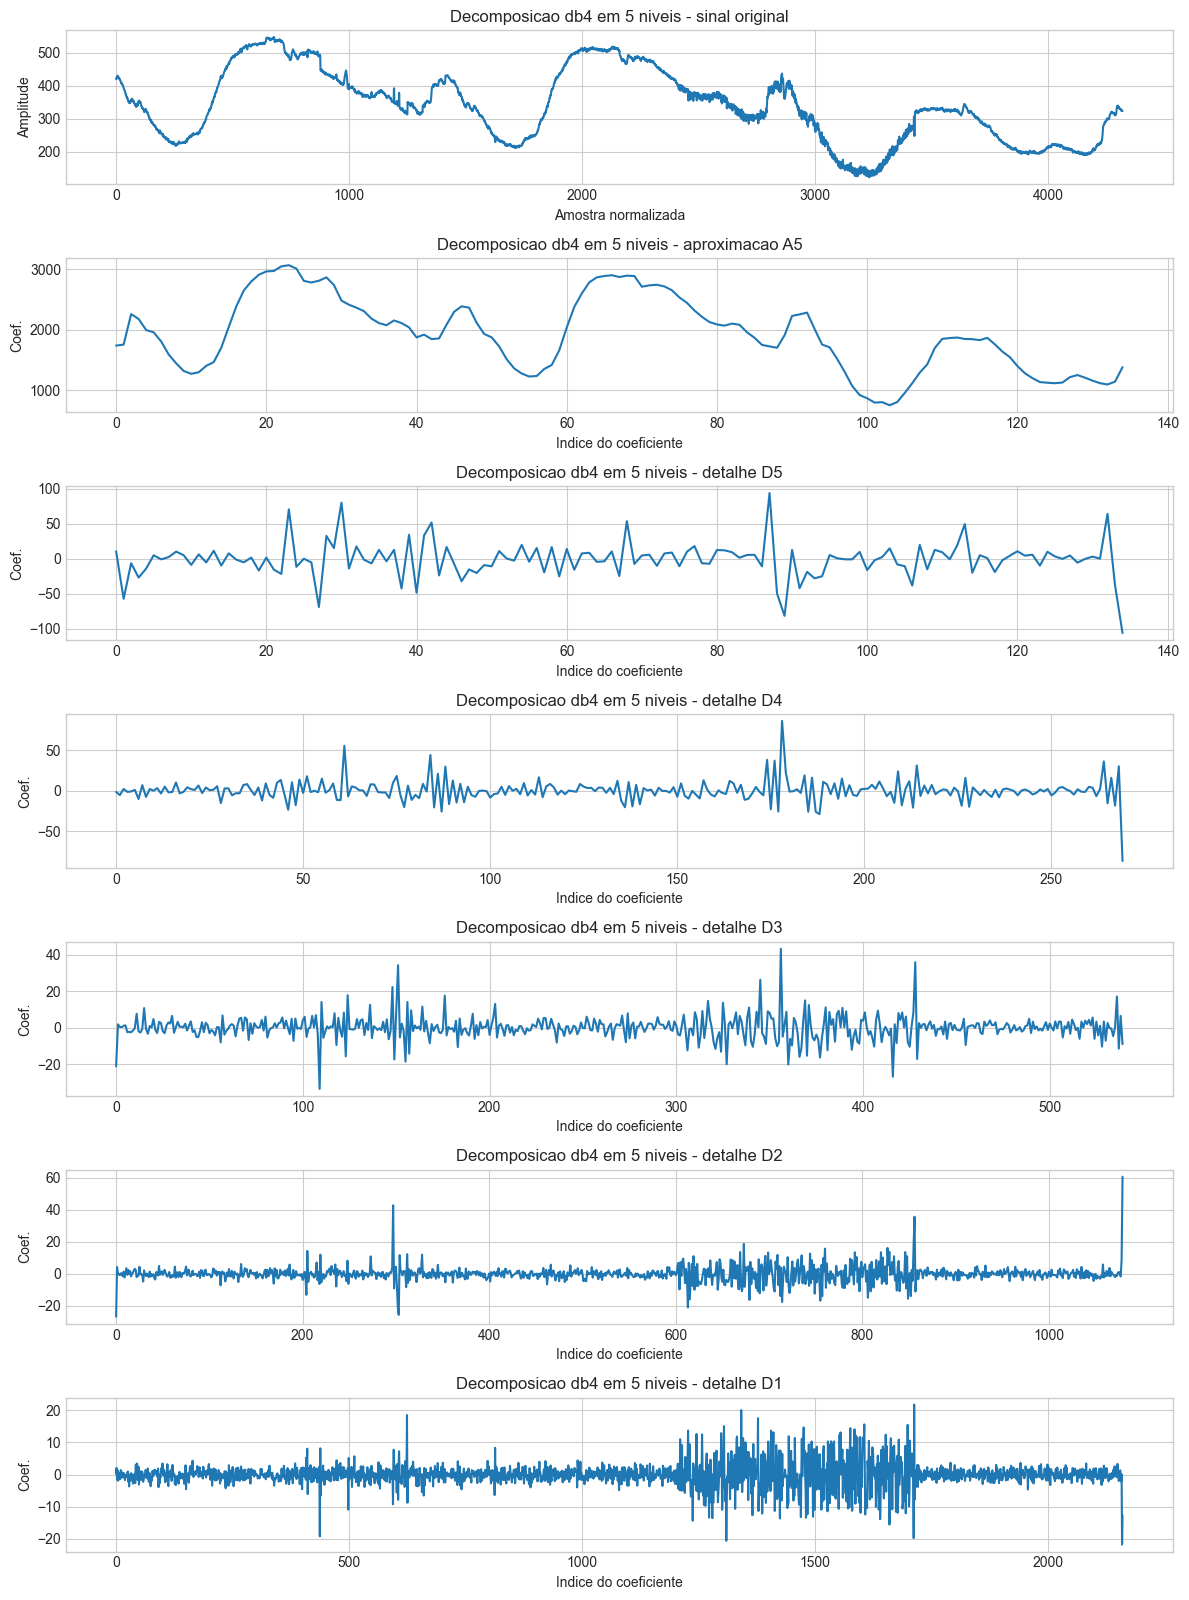

In [3]:
print('Filtros da wavelet db4:')
display_rows(coeffs_table('db4'))

coeffs = pywt.wavedec(x, 'db4', level=5, mode='periodization')
plot_wavelet_decomposition(x, coeffs, 'Decomposicao db4 em 5 niveis')


In [4]:
rows = []
for idx, c in enumerate(coeffs):
    if idx == 0:
        rows.append({'Subfaixa': 'A5', 'Comprimento': len(c), 'Energia': float(np.sum(c ** 2))})
    else:
        level = 6 - idx
        rows.append({'Subfaixa': f'D{level}', 'Comprimento': len(c), 'Energia': float(np.sum(c ** 2))})

display_rows(rows, float_digits=8)


Subfaixa | Comprimento | Energia           
---------+-------------+-------------------
A5       | 135         | 547822862.70607352
D5       | 135         | 89760.76985224    
D4       | 270         | 48251.08038143    
D3       | 540         | 22751.99641656    
D2       | 1080        | 27132.39955868    
D1       | 2160        | 28669.30354754    


In [5]:
sigma_est = np.median(np.abs(coeffs[-1])) / 0.6745
base_threshold = sigma_est * np.sqrt(2 * np.log(len(x)))
factors = [0.5, 1.0, 1.5]

def wavelet_denoise(coeffs_in, threshold):
    den = [pywt.threshold(coeffs_in[0], threshold, mode='soft')]
    den.extend(pywt.threshold(c, threshold, mode='soft') for c in coeffs_in[1:])
    return den, pywt.waverec(den, 'db4', mode='periodization')[:len(x)]

def dft_denoise(signal_in, threshold):
    X = np.fft.fft(signal_in)
    X_den = X.copy()
    X_den[np.abs(X_den) < threshold] = 0
    return np.real(np.fft.ifft(X_den))

wavelet_rows = []
dft_rows = []
wavelet_results = {}
dft_results = {}

for factor in factors:
    threshold = factor * base_threshold
    den_coeffs, den_signal = wavelet_denoise(coeffs, threshold)
    wavelet_results[factor] = (den_coeffs, den_signal)
    wavelet_rows.append(
        {
            'Fator do limiar': factor,
            'Limiar': threshold,
            'MSE vs sinal original': mse(x, den_signal),
            'Desvio padrao do residuo': float(np.std(x - den_signal)),
        }
    )

    dft_signal = dft_denoise(x, threshold)
    dft_results[factor] = dft_signal
    dft_rows.append(
        {
            'Fator do limiar': factor,
            'Limiar': threshold,
            'MSE vs sinal original': mse(x, dft_signal),
            'Desvio padrao do residuo': float(np.std(x - dft_signal)),
        }
    )

print('Resultados com limiarizacao em wavelets:')
display_rows(wavelet_rows, float_digits=8)
print('\nResultados com limiarizacao na DFT:')
display_rows(dft_rows, float_digits=8)


Resultados com limiarizacao em wavelets:
Fator do limiar | Limiar      | MSE vs sinal original | Desvio padrao do residuo
----------------+-------------+-----------------------+-------------------------
0.50000000      | 3.98833611  | 6.35596466            | 2.42051159              
1.00000000      | 7.97667223  | 15.18380750           | 3.63255480              
1.50000000      | 11.96500834 | 23.47866890           | 4.35945804              

Resultados com limiarizacao na DFT:
Fator do limiar | Limiar      | MSE vs sinal original | Desvio padrao do residuo
----------------+-------------+-----------------------+-------------------------
0.50000000      | 3.98833611  | 0.00000010            | 0.00031658              
1.00000000      | 7.97667223  | 0.00001229            | 0.00350505              
1.50000000      | 11.96500834 | 0.00003540            | 0.00595021              


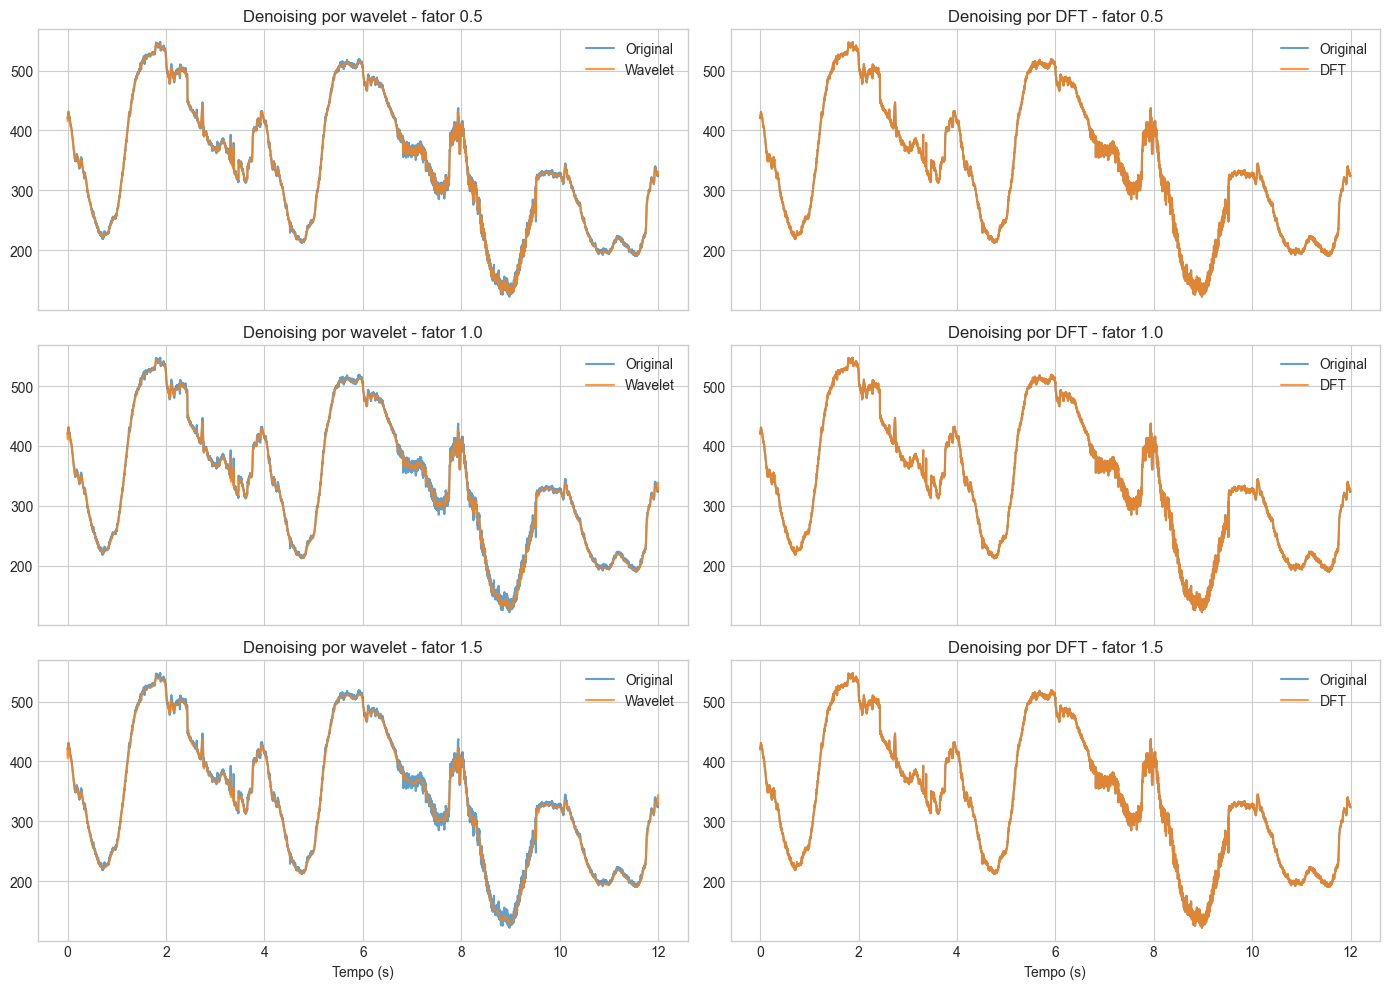

In [6]:
fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex=True)
for idx, factor in enumerate(factors):
    den_coeffs, den_signal = wavelet_results[factor]
    axes[idx, 0].plot(t, x, label='Original', alpha=0.7)
    axes[idx, 0].plot(t, den_signal, label='Wavelet', alpha=0.8)
    axes[idx, 0].set_title(f'Denoising por wavelet - fator {factor}')
    axes[idx, 0].legend()

    axes[idx, 1].plot(t, x, label='Original', alpha=0.7)
    axes[idx, 1].plot(t, dft_results[factor], label='DFT', alpha=0.8)
    axes[idx, 1].set_title(f'Denoising por DFT - fator {factor}')
    axes[idx, 1].legend()

axes[-1, 0].set_xlabel('Tempo (s)')
axes[-1, 1].set_xlabel('Tempo (s)')
plt.tight_layout()
plt.show()


## Comentários

- A limiarização em wavelets atua por subfaixas e tende a preservar melhor estruturas locais importantes do sinal.
- A limiarização na DFT é global e pode suavizar o ruído, mas também remover componentes úteis quando o limiar cresce.
- O fator de limiar controla diretamente o compromisso entre supressão de ruído e distorção do sinal reconstruído.
